# Retail Loan Default Prediction - Exploratory Data Analysis

This notebook covers the initial high-level data profiling and EDA of the 2.26 million row LendingClub dataset.
We are using `pandas` chunking and downcasting to ensure memory-efficient loading.

In [1]:
import pandas as pd
import os
import sys

# Add src directory to path to import our custom data loader
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from src.data_loader import load_data_chunked

# Set pandas options to view more columns during EDA
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_rows', 20)

file_path = r"C:\Users\siddp\Downloads\Dataset for default loan prediction\loan.csv"

# Load data using chunking and memory optimization
df = load_data_chunked(file_path, chunk_size=250000)

Loading data from: C:\Users\siddp\Downloads\Dataset for default loan prediction\loan.csv in chunks of 250000...


Processed 1250000 rows...


Processed 2500000 rows...


C:\Users\siddp\Downloads\HackRush_2026\Retail_Loan_Default_Prediction\src\data_loader.py:59: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat(chunks, ignore_index=True)


Data loaded and optimized successfully in 47.86 seconds.
Dataset Shape: (2260668, 145)


Optimized Memory Usage: 3594.93 MB


In [2]:
# Peek at the first few rows
df.head()

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,pymnt_plan,url,desc,purpose,title,zip_code,addr_state,dti,...,sec_app_collections_12_mths_ex_med,sec_app_mths_since_last_major_derog,hardship_flag,hardship_type,hardship_reason,hardship_status,deferral_term,hardship_amount,hardship_start_date,hardship_end_date,payment_plan_start_date,hardship_length,hardship_dpd,hardship_loan_status,orig_projected_additional_accrued_interest,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,NaN,NaN,2500,2500,2500.0,36 months,13.560000,84.919998,C,C1,Chef,10+ years,RENT,55000.0,Not Verified,Dec-2018,Current,n,NaN,NaN,debt_consolidation,Debt consolidation,109xx,NY,18.24,...,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,30000,30000,30000.0,60 months,18.940001,777.229980,D,D2,Postmaster,10+ years,MORTGAGE,90000.0,Source Verified,Dec-2018,Current,n,NaN,NaN,debt_consolidation,Debt consolidation,713xx,LA,26.52,...,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,5000,5000,5000.0,36 months,17.969999,180.690002,D,D1,Administrative,6 years,MORTGAGE,59280.0,Source Verified,Dec-2018,Current,n,NaN,NaN,debt_consolidation,Debt consolidation,490xx,MI,10.51,...,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,4000,4000,4000.0,36 months,18.940001,146.509995,D,D2,IT Supervisor,10+ years,MORTGAGE,92000.0,Source Verified,Dec-2018,Current,n,NaN,NaN,debt_consolidation,Debt consolidation,985xx,WA,16.74,...,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,30000,30000,30000.0,60 months,16.139999,731.780029,C,C4,Mechanic,10+ years,MORTGAGE,57250.0,Not Verified,Dec-2018,Current,n,NaN,NaN,debt_consolidation,Debt consolidation,212xx,MD,26.35,...,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
# Basic Dataset Information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2260668 entries, 0 to 2260667
Columns: 145 entries, id to settlement_term
dtypes: category(11), float32(90), float64(15), int32(3), int8(1), object(25)
memory usage: 1.5+ GB


In [4]:
df.describe()

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,int_rate,installment,annual_inc,url,dti,delinq_2yrs,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,out_prncp,out_prncp_inv,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,...,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,revol_bal_joint,sec_app_inq_last_6mths,sec_app_mort_acc,sec_app_open_acc,sec_app_revol_util,sec_app_open_act_il,sec_app_num_rev_accts,sec_app_chargeoff_within_12_mths,sec_app_collections_12_mths_ex_med,sec_app_mths_since_last_major_derog,deferral_term,hardship_amount,hardship_length,hardship_dpd,orig_projected_additional_accrued_interest,hardship_payoff_balance_amount,hardship_last_payment_amount,settlement_amount,settlement_percentage,settlement_term
count,0.0,0.0,2.260668e+06,2.260668e+06,2.260668e+06,2.260668e+06,2.260668e+06,2.260664e+06,0.0,2.258957e+06,2.260639e+06,2.260638e+06,1.102166e+06,359156.000000,2.260639e+06,2.260639e+06,2.260668e+06,2.258866e+06,2.260639e+06,2.260668e+06,2.260668e+06,2.260668e+06,2.260668e+06,2.260668e+06,2.260668e+06,...,2.260563e+06,2.190392e+06,2.210638e+06,2.210638e+06,2.190392e+06,1.080200e+05,108021.000000,108021.000000,108021.000000,106184.000000,108021.000000,108021.000000,108021.000000,108021.000000,35942.000000,10613.0,10613.000000,10613.0,10613.000000,8426.000000,10613.000000,10613.000000,33056.000000,33056.000000,33056.000000
mean,NaN,NaN,1.504693e+04,1.504166e+04,1.502344e+04,1.309291e+01,4.458076e+02,7.799243e+04,NaN,1.882420e+01,3.068792e-01,5.768354e-01,3.454092e+01,72.312843,1.161240e+01,1.975278e-01,1.665846e+04,5.033770e+01,2.416255e+01,4.446293e+03,4.445294e+03,1.182403e+04,1.180594e+04,9.300143e+03,2.386352e+03,...,4.677109e-02,1.782428e+05,5.102294e+04,2.319377e+04,4.373201e+04,3.361728e+04,0.633256,1.538997,11.469455,58.169098,3.010554,12.533072,0.046352,0.077568,36.937927,3.0,155.006683,3.0,13.686422,454.840790,11628.036133,193.606339,5030.606934,47.775600,13.148597
std,NaN,NaN,9.190245e+03,9.188413e+03,9.192332e+03,4.832114e+00,2.671737e+02,1.126962e+05,NaN,1.418333e+01,8.672303e-01,8.859631e-01,2.190047e+01,26.464094,5.640862e+00,5.705150e-01,2.294831e+04,2.471307e+01,1.198753e+01,7.547612e+03,7.546657e+03,9.889599e+03,9.884835e+03,8.304886e+03,2.663086e+03,...,3.775338e-01,1.815748e+05,4.991124e+04,2.300656e+04,4.507298e+04,2.815388e+04,0.993401,1.760569,6.627271,25.548212,3.275893,8.150964,0.411496,0.407996,23.924583,0.0,129.113144,0.0,9.728138,375.830750,7615.161133,198.694366,3692.027832,7.336379,8.192319
min,NaN,NaN,5.000000e+02,5.000000e+02,0.000000e+00,5.310000e+00,4.930000e+00,0.000000e+00,NaN,-1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,0.640000,3.0,0.000000,1.920000,55.730000,0.010000,44.209999,0.200000,0.000000
25%,NaN,NaN,8.000000e+03,8.000000e+03,8.000000e+03,9.490000e+00,2.516500e+02,4.600000e+04,NaN,1.189000e+01,0.000000e+00,0.000000e+00,1.600000e+01,55.000000,8.000000e+00,0.000000e+00,5.950000e+03,3.150000e+01,1.500000e+01,0.000000e+00,0.000000e+00,4.272580e+03,4.257730e+03,2.846180e+03,6.936100e+02,...,0.000000e+00,5.073100e+04,2.089200e+04,8.300000e+03,1.500000e+04,1.510675e+04,0.000000,0.000000,7.000000,39.799999,1.000000,7.000000,0.000000,0.000000,16.000000,3.0,59.369999,3.0,5.000000,174.967499,5628.729980,43.779999,2227.000000,45.000000,6.000000
50%,NaN,NaN,1.290000e+04,1.287500e+04,1.280000e+04,1.262000e+01,3.779900e+02,6.500000e+04,NaN,1.784000e+01,0.000000e+00,0.000000e+00,3.100000e+01,74.000000,1.100000e+01,0.000000e+00,1.132400e+04,5.030000e+01,2.200000e+01,0.000000e+00,0.000000e+00,9.060870e+03,9.043080e+03,6.823385e+03,1.485280e+03,...,0.00000

In [5]:
df.shape

(2260668, 145)

## Day 4: Missing Value Analysis
Let's analyze the proportion of missing values across all columns.

C:\Users\siddp\AppData\Local\Temp\ipykernel_42600\533532694.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=missing_percent.index[:50], y=missing_percent.values[:50], palette='viridis')


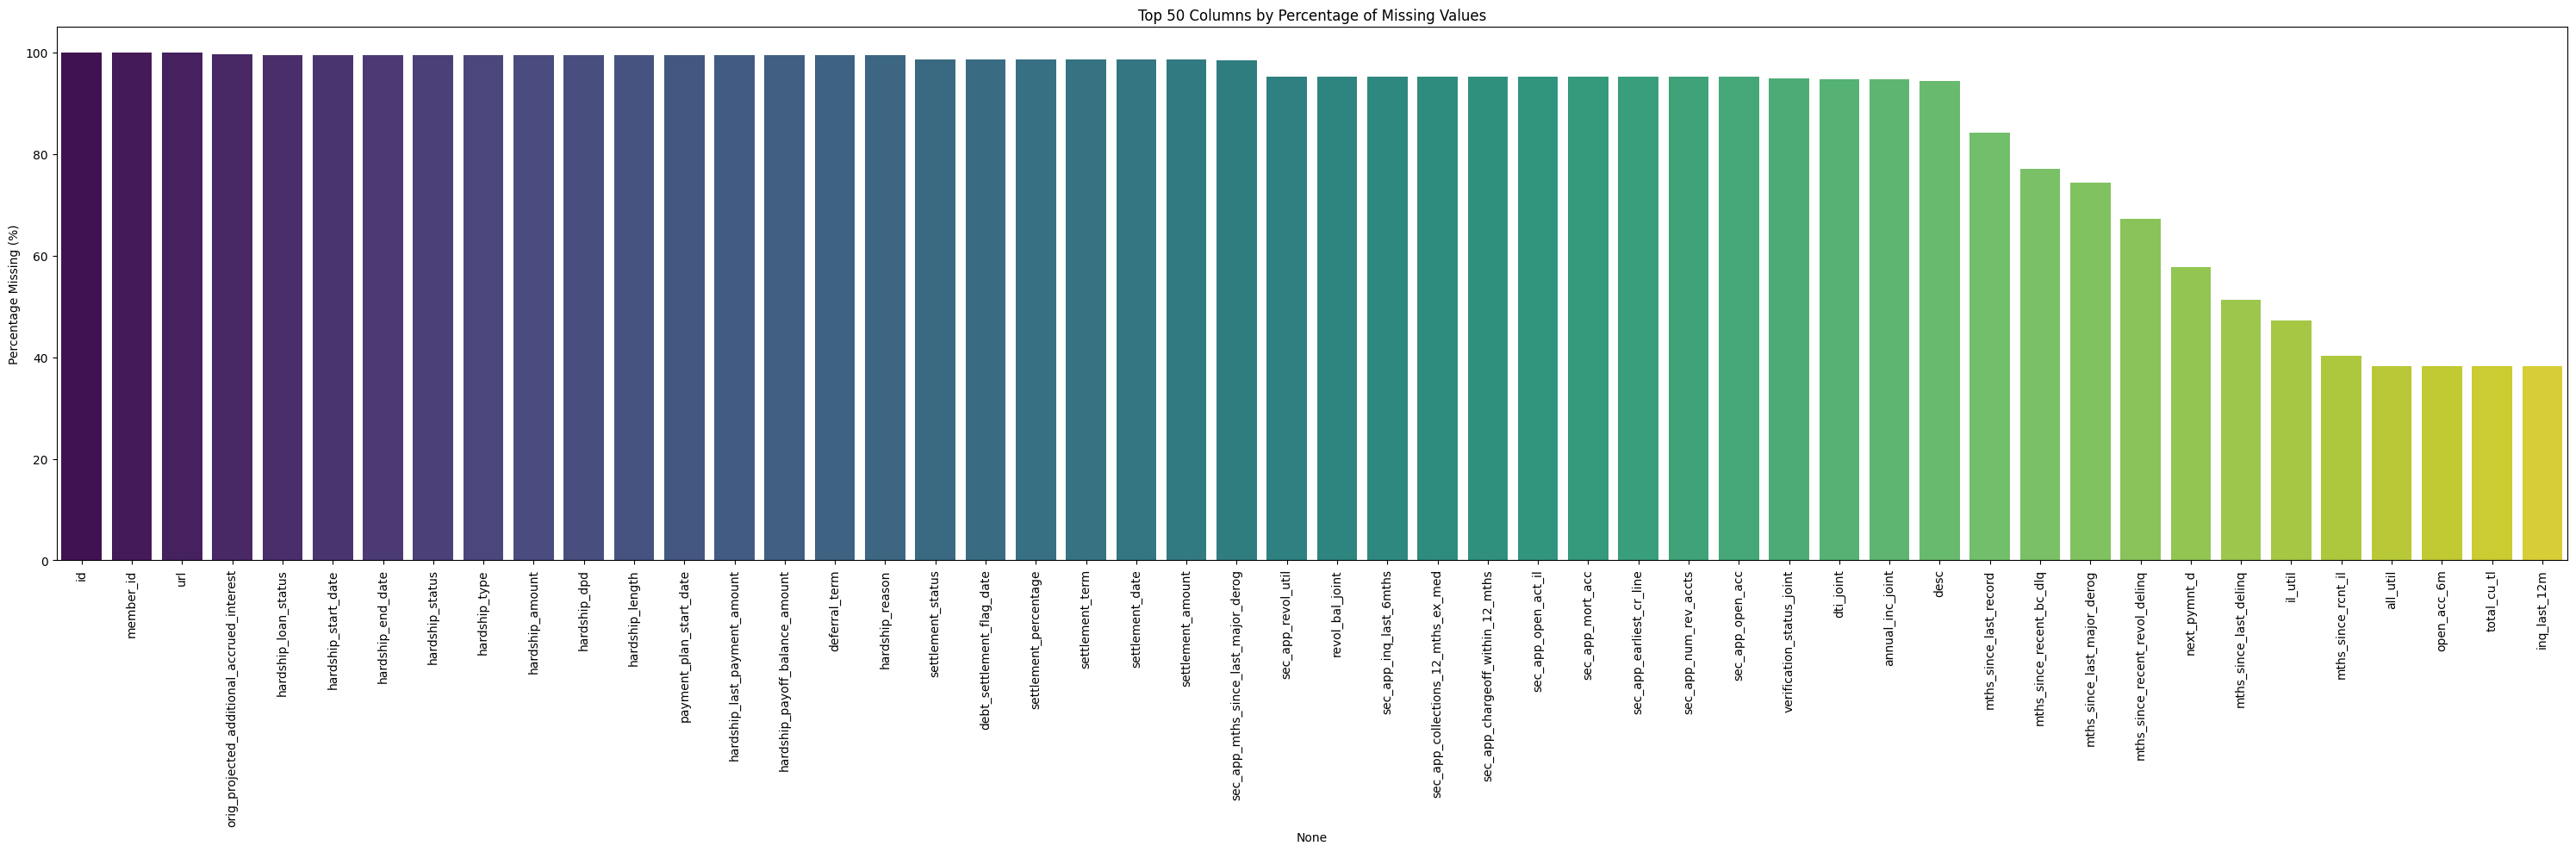

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate missing value percentages
missing_percent = (df.isnull().sum() / len(df)) * 100
missing_percent = missing_percent[missing_percent > 0].sort_values(ascending=False)

plt.figure(figsize=(30, 10))
sns.barplot(x=missing_percent.index[:50], y=missing_percent.values[:50], palette='viridis')
plt.xticks(rotation=90)
plt.title('Top 50 Columns by Percentage of Missing Values')
plt.ylabel('Percentage Missing (%)')
plt.tight_layout()
plt.show()

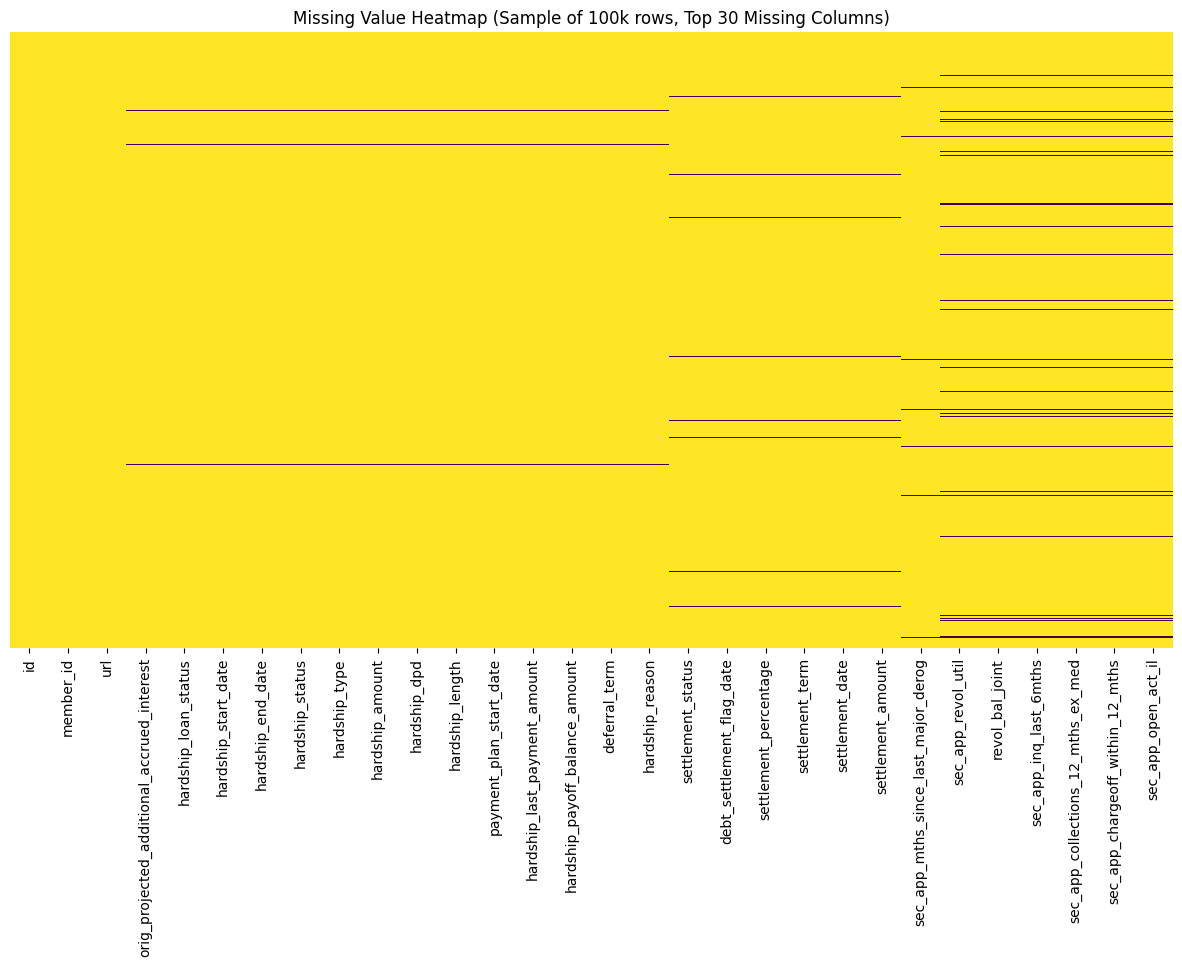

In [7]:
# Plotting missing value heatmap for a random sample of 100k rows to avoid memory crash
plt.figure(figsize=(15, 8))
sample_df = df.sample(n=100000, random_state=42)
# Select columns with missing values to make heatmap readable
cols_with_missing = missing_percent.index[:30] # Top 30 missing
sns.heatmap(sample_df[cols_with_missing].isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title('Missing Value Heatmap (Sample of 100k rows, Top 30 Missing Columns)')
plt.show()

## Day 5: Univariate Analysis
Visualizing distributions of key features.

C:\Users\siddp\AppData\Local\Temp\ipykernel_42600\2479917726.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='loan_status', data=df, order=df['loan_status'].value_counts().index, palette='magma')


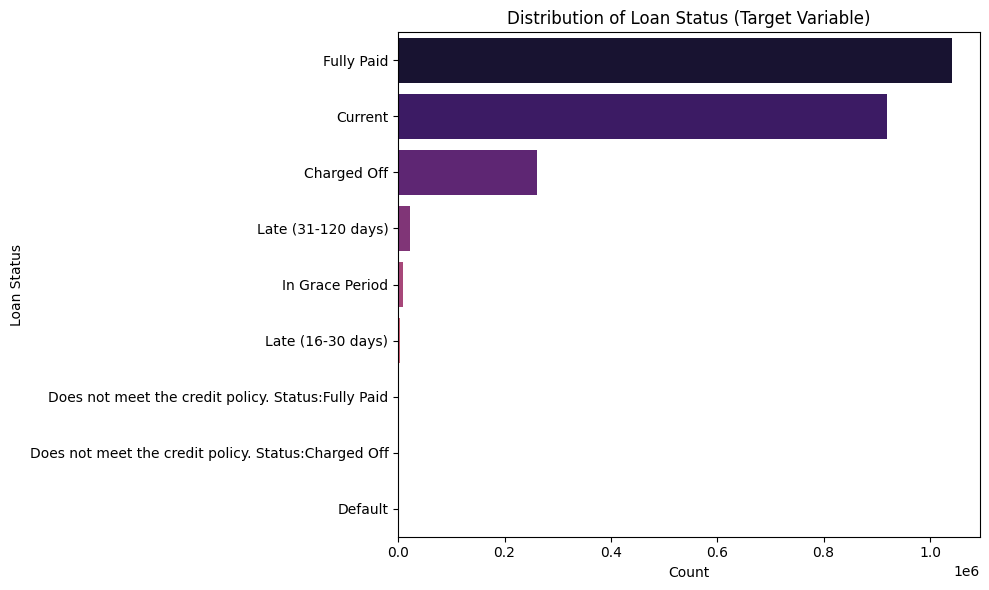

In [8]:
# Target Variable Distribution
plt.figure(figsize=(10, 6))
sns.countplot(y='loan_status', data=df, order=df['loan_status'].value_counts().index, palette='magma')
plt.title('Distribution of Loan Status (Target Variable)')
plt.xlabel('Count')
plt.ylabel('Loan Status')
plt.tight_layout()
plt.show()

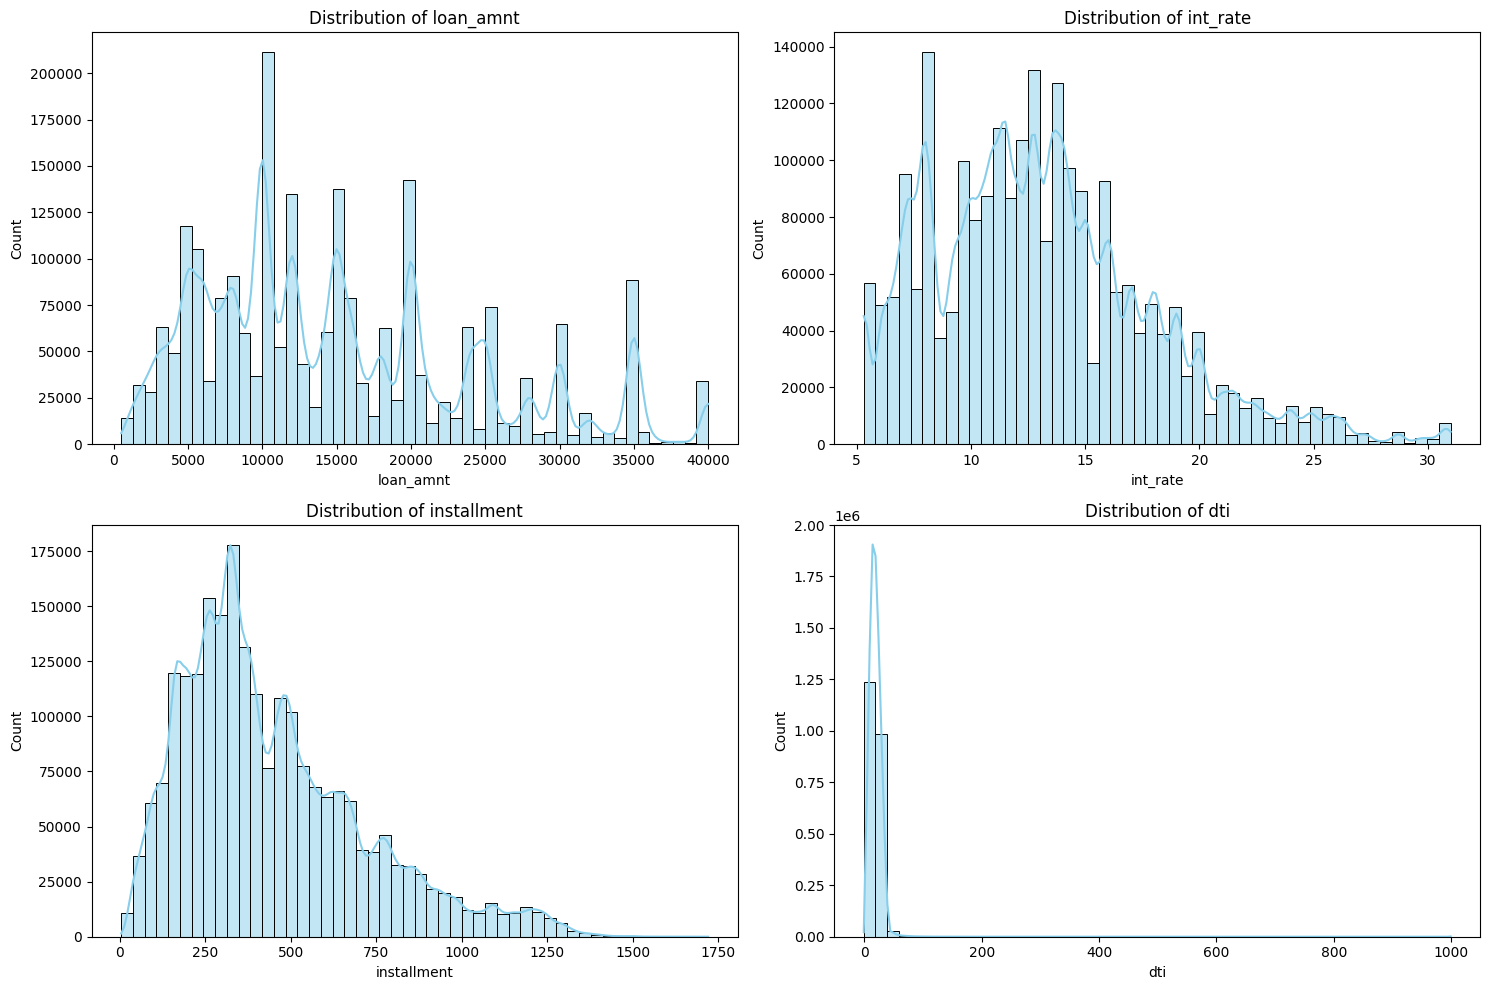

In [9]:
# Numerical Features Distribution
num_features = ['loan_amnt', 'int_rate', 'installment', 'dti']

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for i, feature in enumerate(num_features):
    sns.histplot(df[feature], bins=50, kde=True, ax=axes[i], color='skyblue')
    axes[i].set_title(f'Distribution of {feature}')
    
plt.tight_layout()
plt.show()

C:\Users\siddp\AppData\Local\Temp\ipykernel_42600\341005673.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=feature, data=df, order=df[feature].value_counts().index[:15], ax=axes[i], palette='Set2')


C:\Users\siddp\AppData\Local\Temp\ipykernel_42600\341005673.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=feature, data=df, order=df[feature].value_counts().index[:15], ax=axes[i], palette='Set2')


C:\Users\siddp\AppData\Local\Temp\ipykernel_42600\341005673.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=feature, data=df, order=df[feature].value_counts().index[:15], ax=axes[i], palette='Set2')


C:\Users\siddp\AppData\Local\Temp\ipykernel_42600\341005673.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=feature, data=df, order=df[feature].value_counts().index[:15], ax=axes[i], palette='Set2')


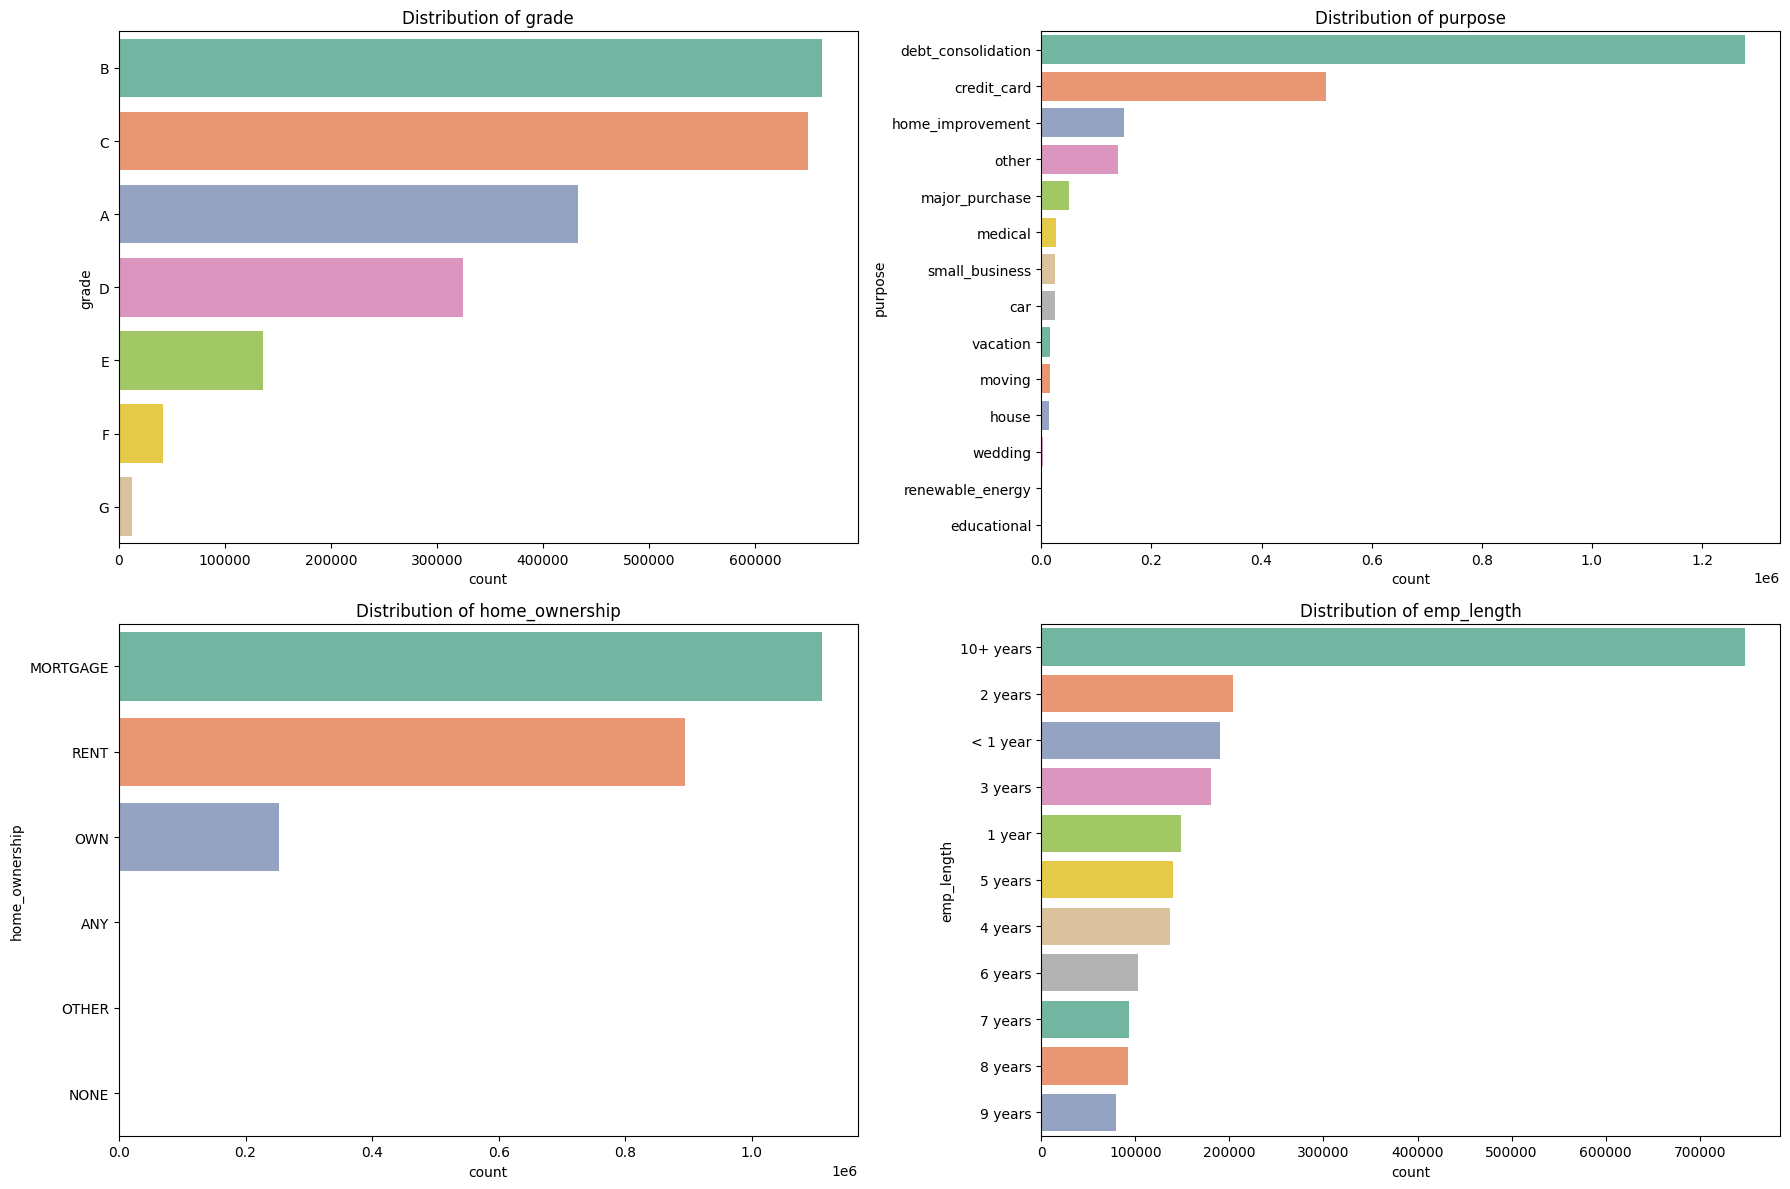

In [10]:
# Categorical Features Distribution
cat_features = ['grade', 'purpose', 'home_ownership', 'emp_length']

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten()

for i, feature in enumerate(cat_features):
    sns.countplot(y=feature, data=df, order=df[feature].value_counts().index[:15], ax=axes[i], palette='Set2')
    axes[i].set_title(f'Distribution of {feature}')
    
plt.tight_layout()
plt.show()